## CatBoost
CatBoost (Categorical Boosting) is a gradient boosting algorithm based on decision trees that is specifically designed to handle categorical features directly by using ordered target statistics and ordered boosting, which reduce overfitting and prediction bias while requiring minimal data preprocessing.

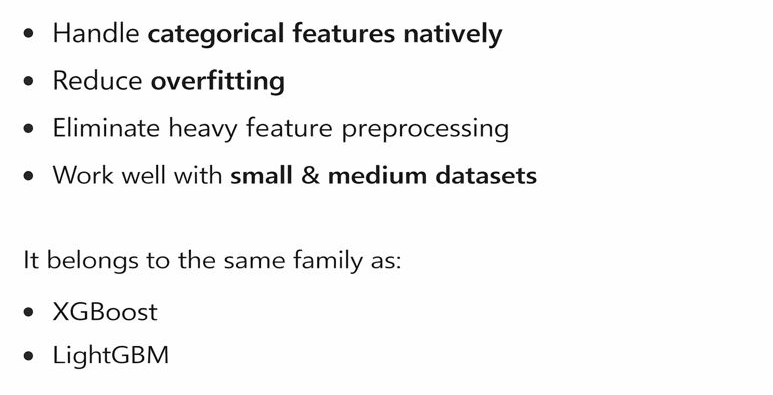

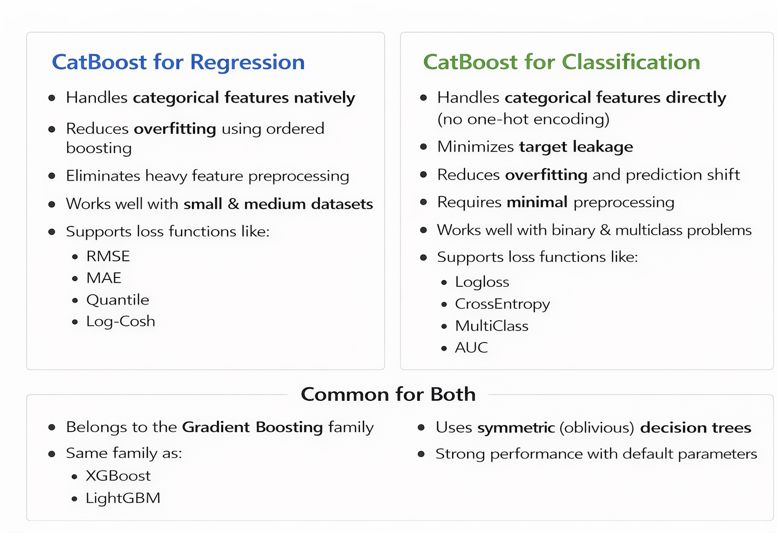

## For Regression

In [21]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [22]:
data = pd.DataFrame({
    "City": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai", "Delhi"],
    "Rooms": [2, 3, 4, 3, 2, 5],
    "Area": [800, 1200, 1500, 1100, 900, 2000],
    "Price": [50, 90, 120, 85, 70, 150]
})

In [23]:
X = data.drop("Price", axis=1)
y = data["Price"]

In [24]:
cat_features = ["City"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
model=CatBoostRegressor(iterations=500,learning_rate=0.05,depth=6,loss_function="RMSE",cat_features=cat_features,verbose=100)

In [27]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

0:	learn: 30.6228540	total: 11.8ms	remaining: 5.89s
100:	learn: 8.1511637	total: 1.65s	remaining: 6.52s
200:	learn: 2.3170214	total: 4.36s	remaining: 6.48s
300:	learn: 0.6586284	total: 6.61s	remaining: 4.37s
400:	learn: 0.1872194	total: 9s	remaining: 2.22s
499:	learn: 0.0537718	total: 11.1s	remaining: 0us


In [29]:
rmse = mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 1193.0753552623078


## For classification

In [10]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [11]:
data = pd.DataFrame({
    "Gender": ["Male", "Female", "Female", "Male", "Female", "Male"],
    "City": ["Delhi", "Mumbai", "Delhi", "Chennai", "Mumbai", "Delhi"],
    "Age": [25, 30, 22, 35, 28, 40],
    "Purchased": [0, 1, 0, 1, 1, 0]
})

In [12]:
X = data.drop("Purchased", axis=1)
y = data["Purchased"]

In [13]:
cat_features = ["Gender", "City"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model = CatBoostClassifier(iterations=400,learning_rate=0.05,depth=6,loss_function="Logloss",
cat_features=cat_features,eval_metric="Accuracy",verbose=100)

In [16]:
model.fit(X_train, y_train)

0:	learn: 1.0000000	total: 58.3ms	remaining: 23.3s
100:	learn: 1.0000000	total: 2.07s	remaining: 6.13s
200:	learn: 1.0000000	total: 4s	remaining: 3.96s
300:	learn: 1.0000000	total: 6.46s	remaining: 2.12s
399:	learn: 1.0000000	total: 8.85s	remaining: 0us


In [20]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

